In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt

In [17]:
#read in data
data=pd.read_csv("../data/Amazon.csv")
data.head()
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  str    
 1   OrderDate      100000 non-null  str    
 2   CustomerID     100000 non-null  str    
 3   CustomerName   100000 non-null  str    
 4   ProductID      100000 non-null  str    
 5   ProductName    100000 non-null  str    
 6   Category       100000 non-null  str    
 7   Brand          100000 non-null  str    
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  str    
 15  OrderStatus    100000 non-null  str    
 16  City           100000 non-null  str    
 17  State          100000 non-null  str    
 

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [ ]:
#data cleaning
print(data.isna().sum())
print(data.duplicated().sum())
#good news the data is well conditioned

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64
0


In [22]:
#basic statistic facts
print("datasize:",data.size)
list_of_brand=data["Brand"].unique()
print(list_of_brand)
start_date=min(data["OrderDate"])
end_date=max(data["OrderDate"])
print("Starting from",start_date,"Ending at",end_date)
cancel_rate=len(data[data["OrderStatus"]=="Cancelled"])/len(data)
print(cancel_rate)
countries=data["Country"].unique()
print(countries)

datasize: 2000000
<StringArray>
[ 'BrightLux', 'UrbanStyle',     'Zenith',   'KiddoFun',   'ReadMore',
       'Apex',   'HomeEase',    'FitLife',   'CoreTech',     'NexPro']
Length: 10, dtype: str
Starting from 2020-01-01 Ending at 2024-12-29
0.03028
<StringArray>
['India', 'United States', 'Canada', 'Australia', 'United Kingdom']
Length: 5, dtype: str


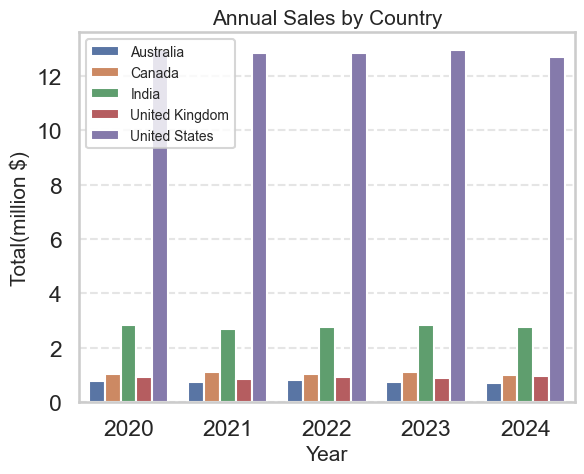

In [63]:
#first thought: we should first find out where our main sales market lies
sns.set_theme(style="whitegrid", context="talk")
df1=data.copy()
df1["OrderDate"]=pd.to_datetime(df1["OrderDate"])
df1["Year"]=df1["OrderDate"].dt.year
df1=(df1.groupby(["Country","Year"],as_index=False)
     .agg(Yearlysales=("TotalAmount","sum")))
df1["Yearlysales"]=df1["Yearlysales"]/1000000
sns.barplot(data=df1,
             x="Year",
             y="Yearlysales",
             hue="Country")
plt.legend(
     loc="best",
     fontsize=10
)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.title("Annual Sales by Country",fontsize=15)
plt.ylabel("Total(million $)",fontsize=15)
plt.xlabel("Year",fontsize=15)
plt.show()

C:\Users\32319\AppData\Local\Temp\ipykernel_36444\508465096.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax=sns.lineplot(data=df2,


,time,Monthlytotal
0,2020-01-01,1153.45227
1,2020-02-01,928.08433
2,2020-03-01,1132.20120
3,2020-04-01,1149.41598
4,2020-05-01,1095.69392


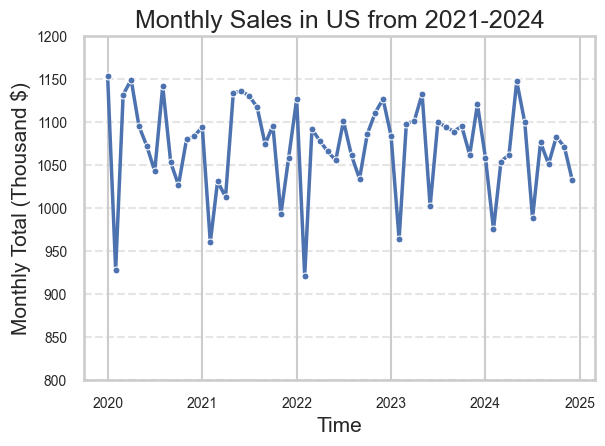

In [84]:
#So we may further focus on the sales change of US
df2=data.copy()
df2=df2[df2["Country"]=="United States"]
df2["OrderDate"]=pd.to_datetime(df2["OrderDate"])
df2["time"]=df2["OrderDate"].dt.to_period("M")
df2=(df2.groupby("time",as_index=False)
     .agg(Monthlytotal=("TotalAmount","sum")))
df2["Monthlytotal"]=df2["Monthlytotal"]/1000
df2["time"] = df2["time"].dt.to_timestamp()
ax=sns.lineplot(data=df2,
             x="time",
             y="Monthlytotal",
             linewidth=2.5,
             marker="o",
             markersize=5,
             palette="palette2",
             )
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.title("Monthly Sales in US from 2021-2024",fontsize=18)
plt.ylabel("Monthly Total (Thousand $)",fontsize=15)
plt.xlabel("Time",fontsize=15)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_ylim(800,1200)
plt.tight_layout()
df2.head()